## Notebook 2 for data vizualisation

In [1]:
# import
import os
import sys
import csv
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# import the merged data file
merged_df = pd.read_csv('fusion_results_merged.csv.gzip', compression='gzip', sep=',', header=0, dtype={'# sample': str, 'Depth': str})
merged_df.head()

,Mg,Al,Si,K,Ca,Ti,Mn,Fe,Rb,Sr,...,U,Sum,Filename,Core,# sample,Depth,Conductivity,# Non-soluble dust,d18O,dD
0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,4364.6397,0.0,0.0,...,0.0,4364.6397,1137 2410,1137,2410,100.00883945750563,0.076415,177.153846,-56.665723,-439.623557
1,0.0,3359.1233,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,...,0.0,3359.1233,1137 2410,1137,2410,100.00883945750563,0.076415,177.153846,-56.665723,-439.623557
2,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,2334.2033,0.0,0.0,...,0.0,2334.2033,1137 2410,1137,2410,100.00883945750563,0.076415,177.153846,-56.665723,-439.623557
3,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,...,0.0,4813.6705,1137 2410,1137,2410,100.00883945750563,0.076415,177.153846,-56.665723,-439.623557
4,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,...,0.0,7756.7880,1137 2410,1137,2410,100.00883945750563,0.076415,177.153846,-56.665723,-439.623557


/var/folders/zk/2_bksjhn0g731cln_7qgt3q00000gn/T/ipykernel_8116/1191494921.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='# sample', y='Depth', data=merged_df_2, palette='viridis')


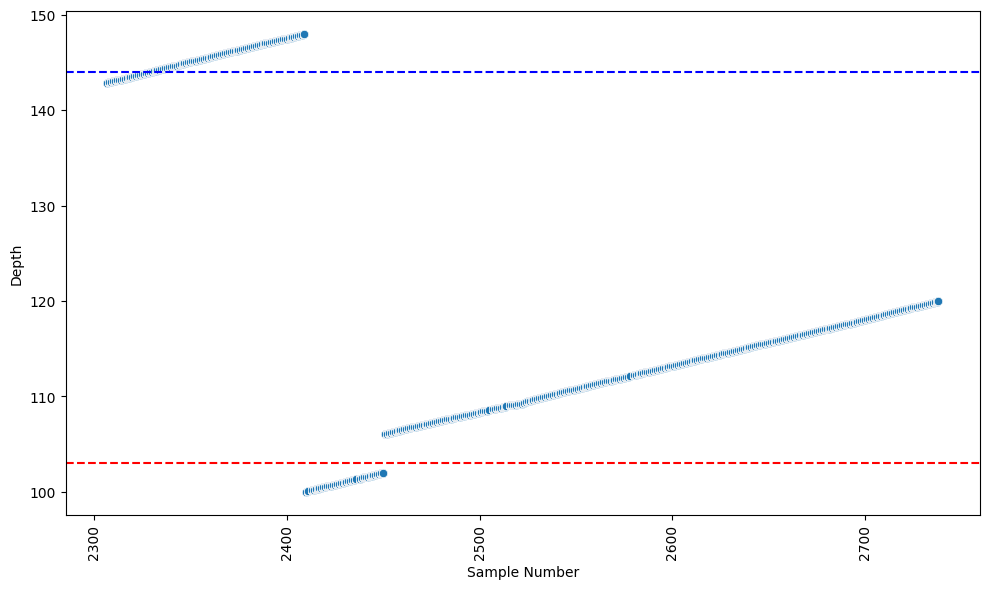

In [3]:
# convert the 'Depth' column to numeric, handling errors by coercing invalid values to NaN
merged_df_2 = merged_df.dropna(subset=['Depth'])
merged_df_2['Depth'] = pd.to_numeric(merged_df['Depth'], errors='coerce')
merged_df_2['# sample'] = pd.to_numeric(merged_df['# sample'])
merged_df_2.sort_values(by='Depth', inplace=True)


# plot the depth vs the sample number
plt.figure(figsize=(10, 6))
#sns.set(style="whitegrid")
sns.scatterplot(x='# sample', y='Depth', data=merged_df_2, palette='viridis')
# draw a horizontal line at y=123
plt.axhline(y=103, color='r', linestyle='--', label='Threshold (123)')
plt.axhline(y=144, color='b', linestyle='--', label='Threshold (123)')
plt.xticks(rotation=90)
plt.grid(False)
plt.xlabel('Sample Number')
plt.ylabel('Depth')

plt.tight_layout()

In [4]:
def plot_element_data(df, element, threshold=0, palette='plasma'):
    fontsize = 20  # Define fontsize variable
    subset = df[[element, 'Filename', 'Depth', 'Conductivity', '# Non-soluble dust', 'd18O', 'dD']][df[element] > threshold]

    fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(40, 20), sharex=True)

    # Boxplot
    sns.boxplot(data=subset, x='Filename', y=element, hue='Filename', palette=palette, order=subset['Filename'].unique(), legend=None, ax=ax[0])
    ax[0].set_ylabel('NP mass (ag)', fontsize=fontsize)
    ax[0].set_yscale('log')
    # set the title on the left corner in the ax
    ax[0].set_title(f'{element}', fontsize=40, fontweight='bold', loc='left')
    ax[0].tick_params(axis='y', labelsize=fontsize)  # BEGIN: Increase y-ticks fontsize
    ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)  # Add grid lines

    # Countplot
    sns.countplot(data=subset, x='Filename', hue='Filename', palette=palette, order=subset['Filename'].unique(), legend=None, ax=ax[1])
    ax[1].set_ylabel('Number of NPs', fontsize=fontsize)
    ax[1].tick_params(axis='y', labelsize=fontsize)  # Increase y-ticks fontsize
    ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)  # Add grid lines

    # Barplot for total mass
    sns.barplot(data=subset, x='Filename', y=element, estimator='sum', hue='Filename', palette=palette, order=subset['Filename'].unique(), legend=None, ax=ax[2])
    ax[2].set_xlabel('')
    ax[2].set_ylabel('Total mass (ag)', fontsize=fontsize)
    ax[2].tick_params(axis='y', labelsize=fontsize)  # Increase y-ticks fontsize
    ax[2].yaxis.offsetText.set_fontsize(fontsize)
    ax[2].grid(True, which='both', linestyle='--', linewidth=0.5)  # Add grid lines
    plt.xticks(rotation=90)

    # First, remove NaNs manually
    subset_clean = subset.dropna(subset=['Filename', 'Depth', 'Conductivity', '# Non-soluble dust', 'd18O', 'dD'])

    # add a second y-axis for Conductivity
    ax1 = ax[0].twinx()
    sns.lineplot(data=subset_clean, x='Filename', y='d18O', color='mediumvioletred', marker='o', ax=ax1, legend=None)
    ax1.set_ylabel('d18O', color='mediumvioletred', fontsize=fontsize)
    ax1.set_xlabel('')
    ax1.tick_params(axis='y', labelcolor='mediumvioletred', labelsize=fontsize)  # Increase y-ticks fontsize
    ax1.grid(False)


    # add a second y-axis for Conductivity
    ax2 = ax[1].twinx()
    sns.lineplot(data=subset_clean, x='Filename', y='# Non-soluble dust', color='red', marker='o', ax=ax2, legend=None)
    ax2.set_ylabel('# Non-soluble dust', color='red', fontsize=fontsize)
    ax2.set_xlabel('')
    ax2.tick_params(axis='y', labelcolor='red', labelsize=fontsize)  # Increase y-ticks fontsize
    ax2.grid(False)


    # add a second y-axis for Conductivity
    ax3 = ax[2].twinx()
    sns.lineplot(data=subset_clean, x='Filename', y='Conductivity', color='darkorange', marker='o', ax=ax3, legend=None)
    ax3.set_ylabel('Conductivity (µS/cm)', color='darkorange', fontsize=fontsize)
    ax3.set_xlabel('')
    ax3.tick_params(axis='y', labelcolor='darkorange', labelsize=fontsize)  # Increase y-ticks fontsize
    ax3.grid(False)

    plt.tight_layout()

    # Save the figure
    output_filename = f'plot_{element}.png'
    plt.savefig(f'Figures/{output_filename}', dpi=300)
    print(f'Plot saved as {output_filename}')

Plot saved as plot_Sum.png


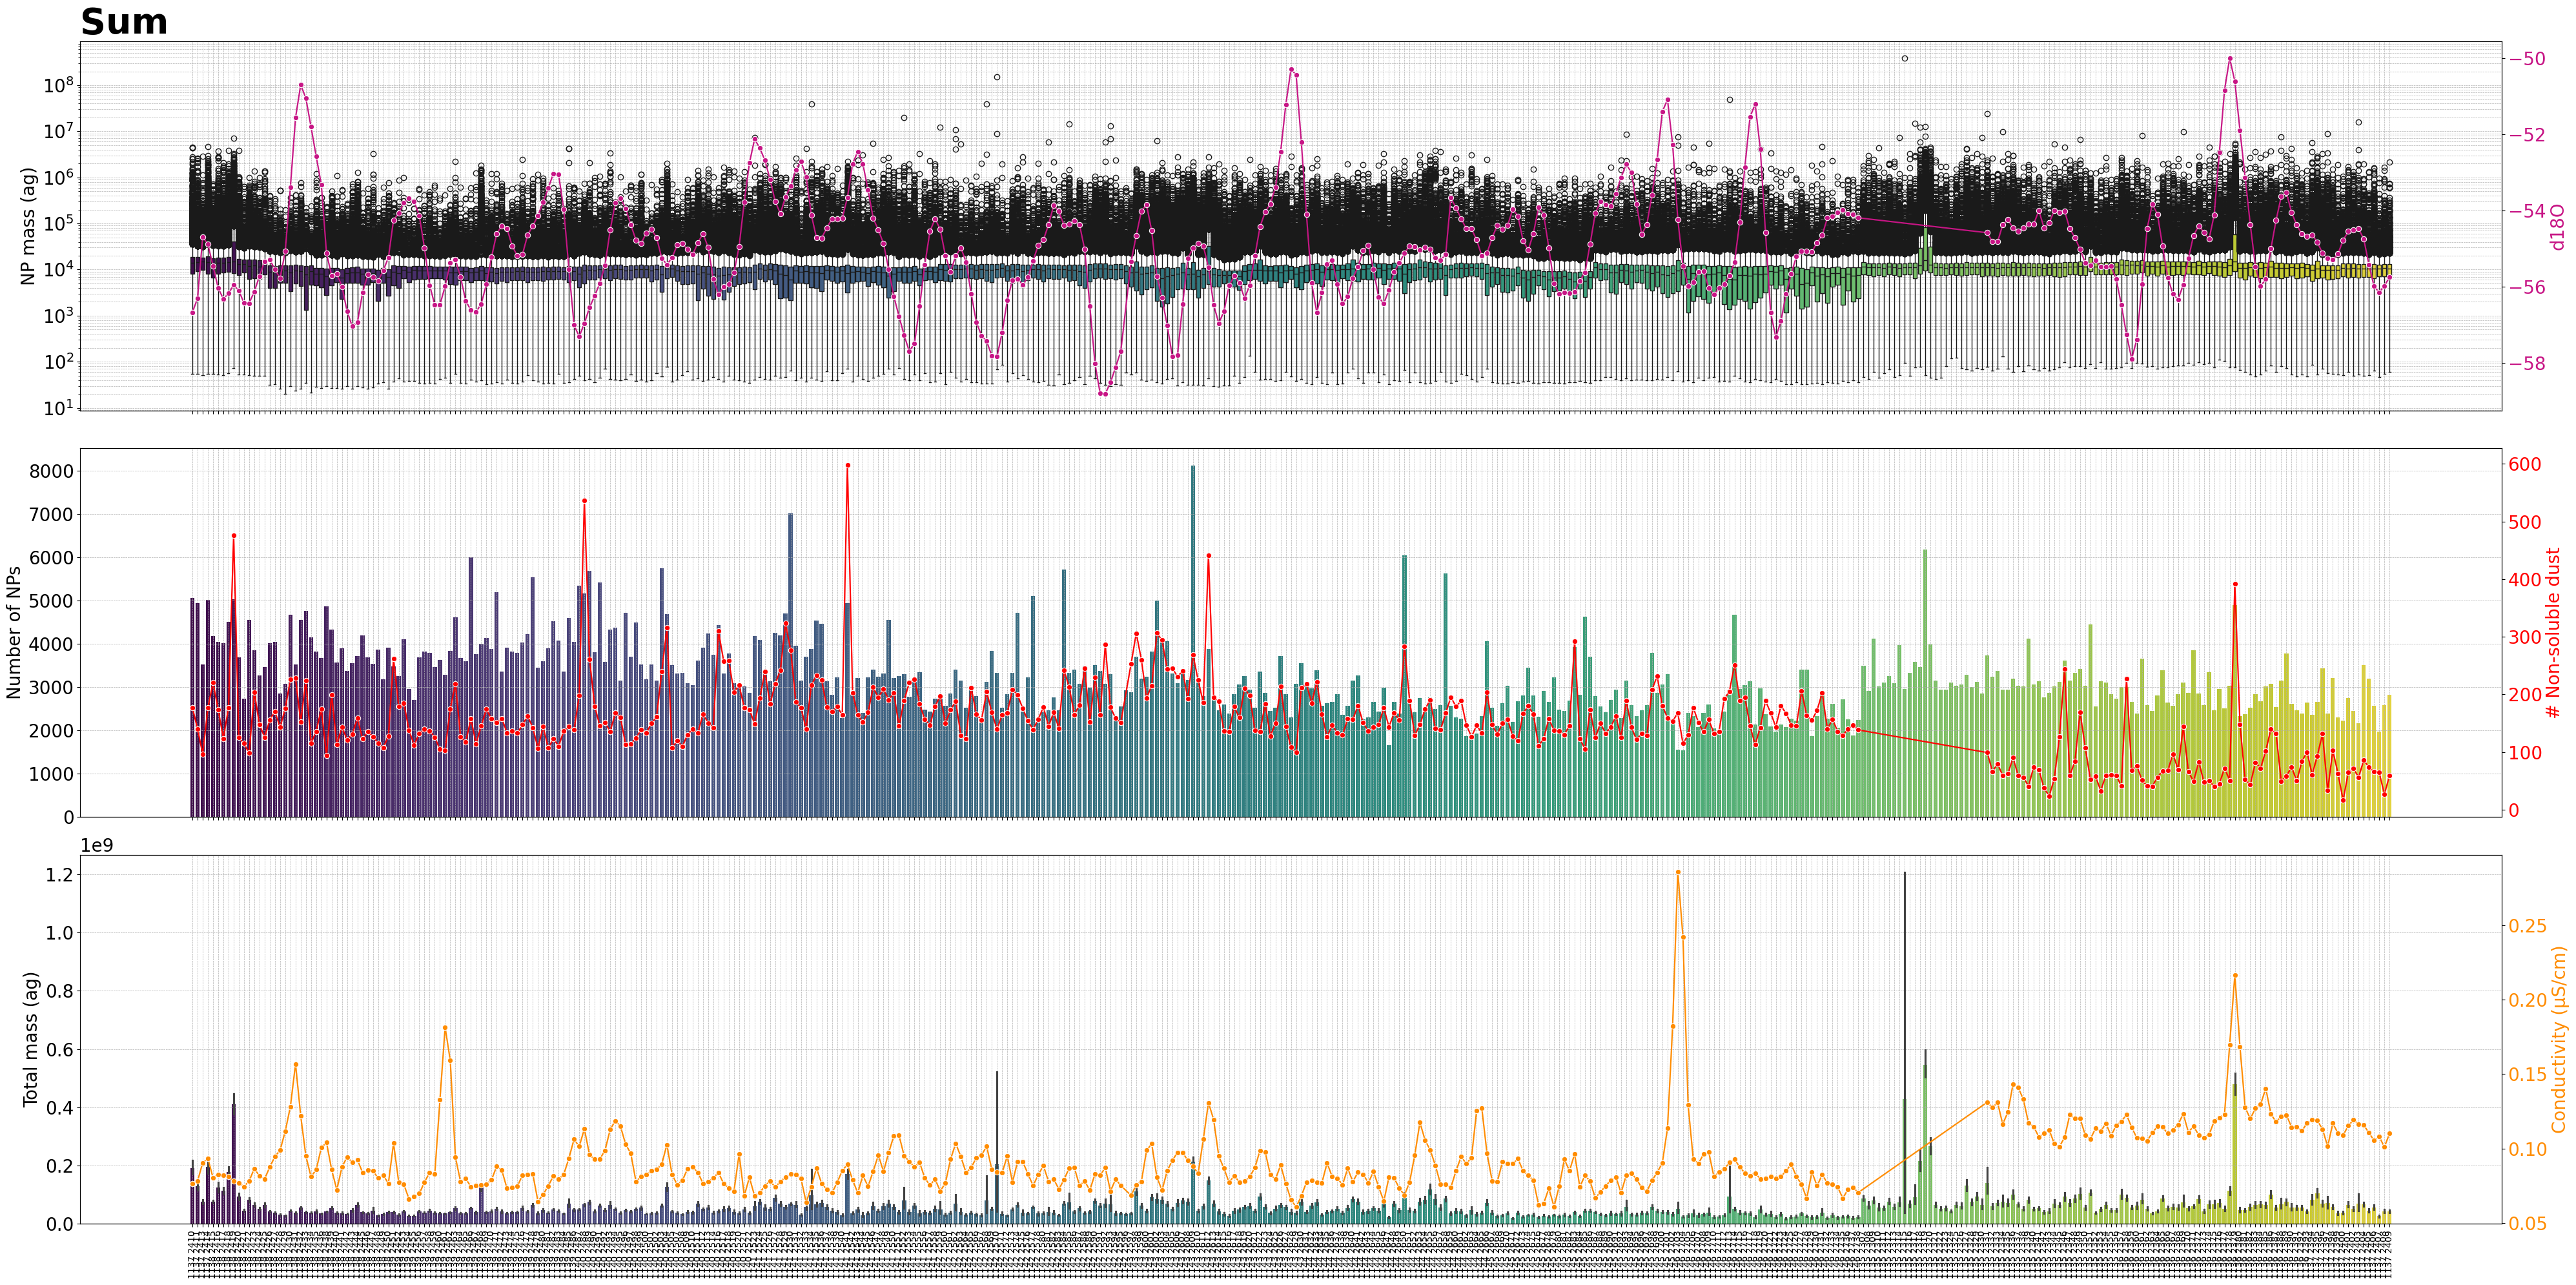

In [11]:
# Plot data
plot_element_data(merged_df_2, 'Sum', threshold=0, palette='viridis')

In [6]:
def plot_Au_data(df, element, threshold=0, palette='plasma'):
    fontsize = 20  # Define fontsize variable
    subset = df[[element, 'Filename', 'Depth', 'Conductivity', '# Non-soluble dust', 'd18O', 'dD']][df[element] > threshold]

    fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(40, 20), sharex=True)

    # Boxplot
    avg = subset[element][subset[element] < 30000].mean()
    sd = subset[element][subset[element] < 30000].std()
    n = len(subset[element][subset[element] < 30000])

    sns.boxplot(data=subset, x='Filename', y=element, hue='Filename', palette=palette, order=subset['Filename'].unique(), legend=None, ax=ax[0])
    ax[0].axhline(y=avg, color='red', linestyle='--', linewidth=5, label=f'Average: {avg:.2f} ag')
    ax[0].fill_between(subset['Filename'].unique(), avg - sd, avg + sd, color='green', alpha=0.3, label=f'SD range: {avg - sd:.2f} to {avg + sd:.2f} ag')
    ax[0].set_ylabel('NP mass (ag)', fontsize=fontsize)
    #ax[0].set_yscale('log')
    ax[0].set_ylim(0, 50000)
    # set the title on the left corner in the ax
    ax[0].set_title(f'{element}', fontsize=40, fontweight='bold', loc='left')
    ax[0].tick_params(axis='y', labelsize=fontsize)  # BEGIN: Increase y-ticks fontsize
    ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)  # Add grid lines

    # Countplot
    np_number_avg = n/len(subset['Filename'].unique())
    np_number_sd = subset['Filename'].value_counts().std()

    sns.countplot(data=subset, x='Filename', hue='Filename', palette=palette, order=subset['Filename'].unique(), legend=None, ax=ax[1])
    ax[1].axhline(y=np_number_avg, color='red', linestyle='--', linewidth=5, label=f'Average # NPs: {np_number_avg:.0f}')
    ax[1].fill_between(subset['Filename'].unique(), np_number_avg - np_number_sd, np_number_avg + np_number_sd, color='green', alpha=0.3, label=f'SD range: {np_number_avg - np_number_sd:.2f} to {np_number_avg + np_number_sd:.2f}')
    ax[1].set_ylabel('Number of NPs', fontsize=fontsize)
    ax[1].tick_params(axis='y', labelsize=fontsize)  # Increase y-ticks fontsize
    ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)  # Add grid lines

    # Barplot for total mass
    np_mass_avg = subset[element].sum() / len(subset['Filename'].unique())
    np_mass_sd = subset.groupby('Filename')[element].sum().std()
    sns.barplot(data=subset, x='Filename', y=element, estimator='sum', hue='Filename', palette=palette, order=subset['Filename'].unique(), legend=None, ax=ax[2])
    ax[2].axhline(y=np_mass_avg, color='red', linestyle='--', linewidth=5, label=f'Average total mass: {np_mass_avg:.2f} ag')
    ax[2].fill_between(subset['Filename'].unique(), np_mass_avg - np_mass_sd, np_mass_avg + np_mass_sd, color='green', alpha=0.3, label=f'SD range: {np_mass_avg - np_mass_sd:.2f} to {np_mass_avg + np_mass_sd:.2f}')
    ax[2].set_xlabel('')
    ax[2].set_ylabel('Total mass (ag)', fontsize=fontsize)
    ax[2].tick_params(axis='y', labelsize=fontsize)  # Increase y-ticks fontsize
    ax[2].yaxis.offsetText.set_fontsize(fontsize)
    ax[2].grid(True, which='both', linestyle='--', linewidth=0.5)  # Add grid lines
    plt.xticks(rotation=90)

    plt.tight_layout()

    # Save the figure
    output_filename = f'plot_{element}.png'
    plt.savefig(f'Figures/{output_filename}', dpi=300)
    print(f'Plot saved as {output_filename}')

Plot saved as plot_Au.png


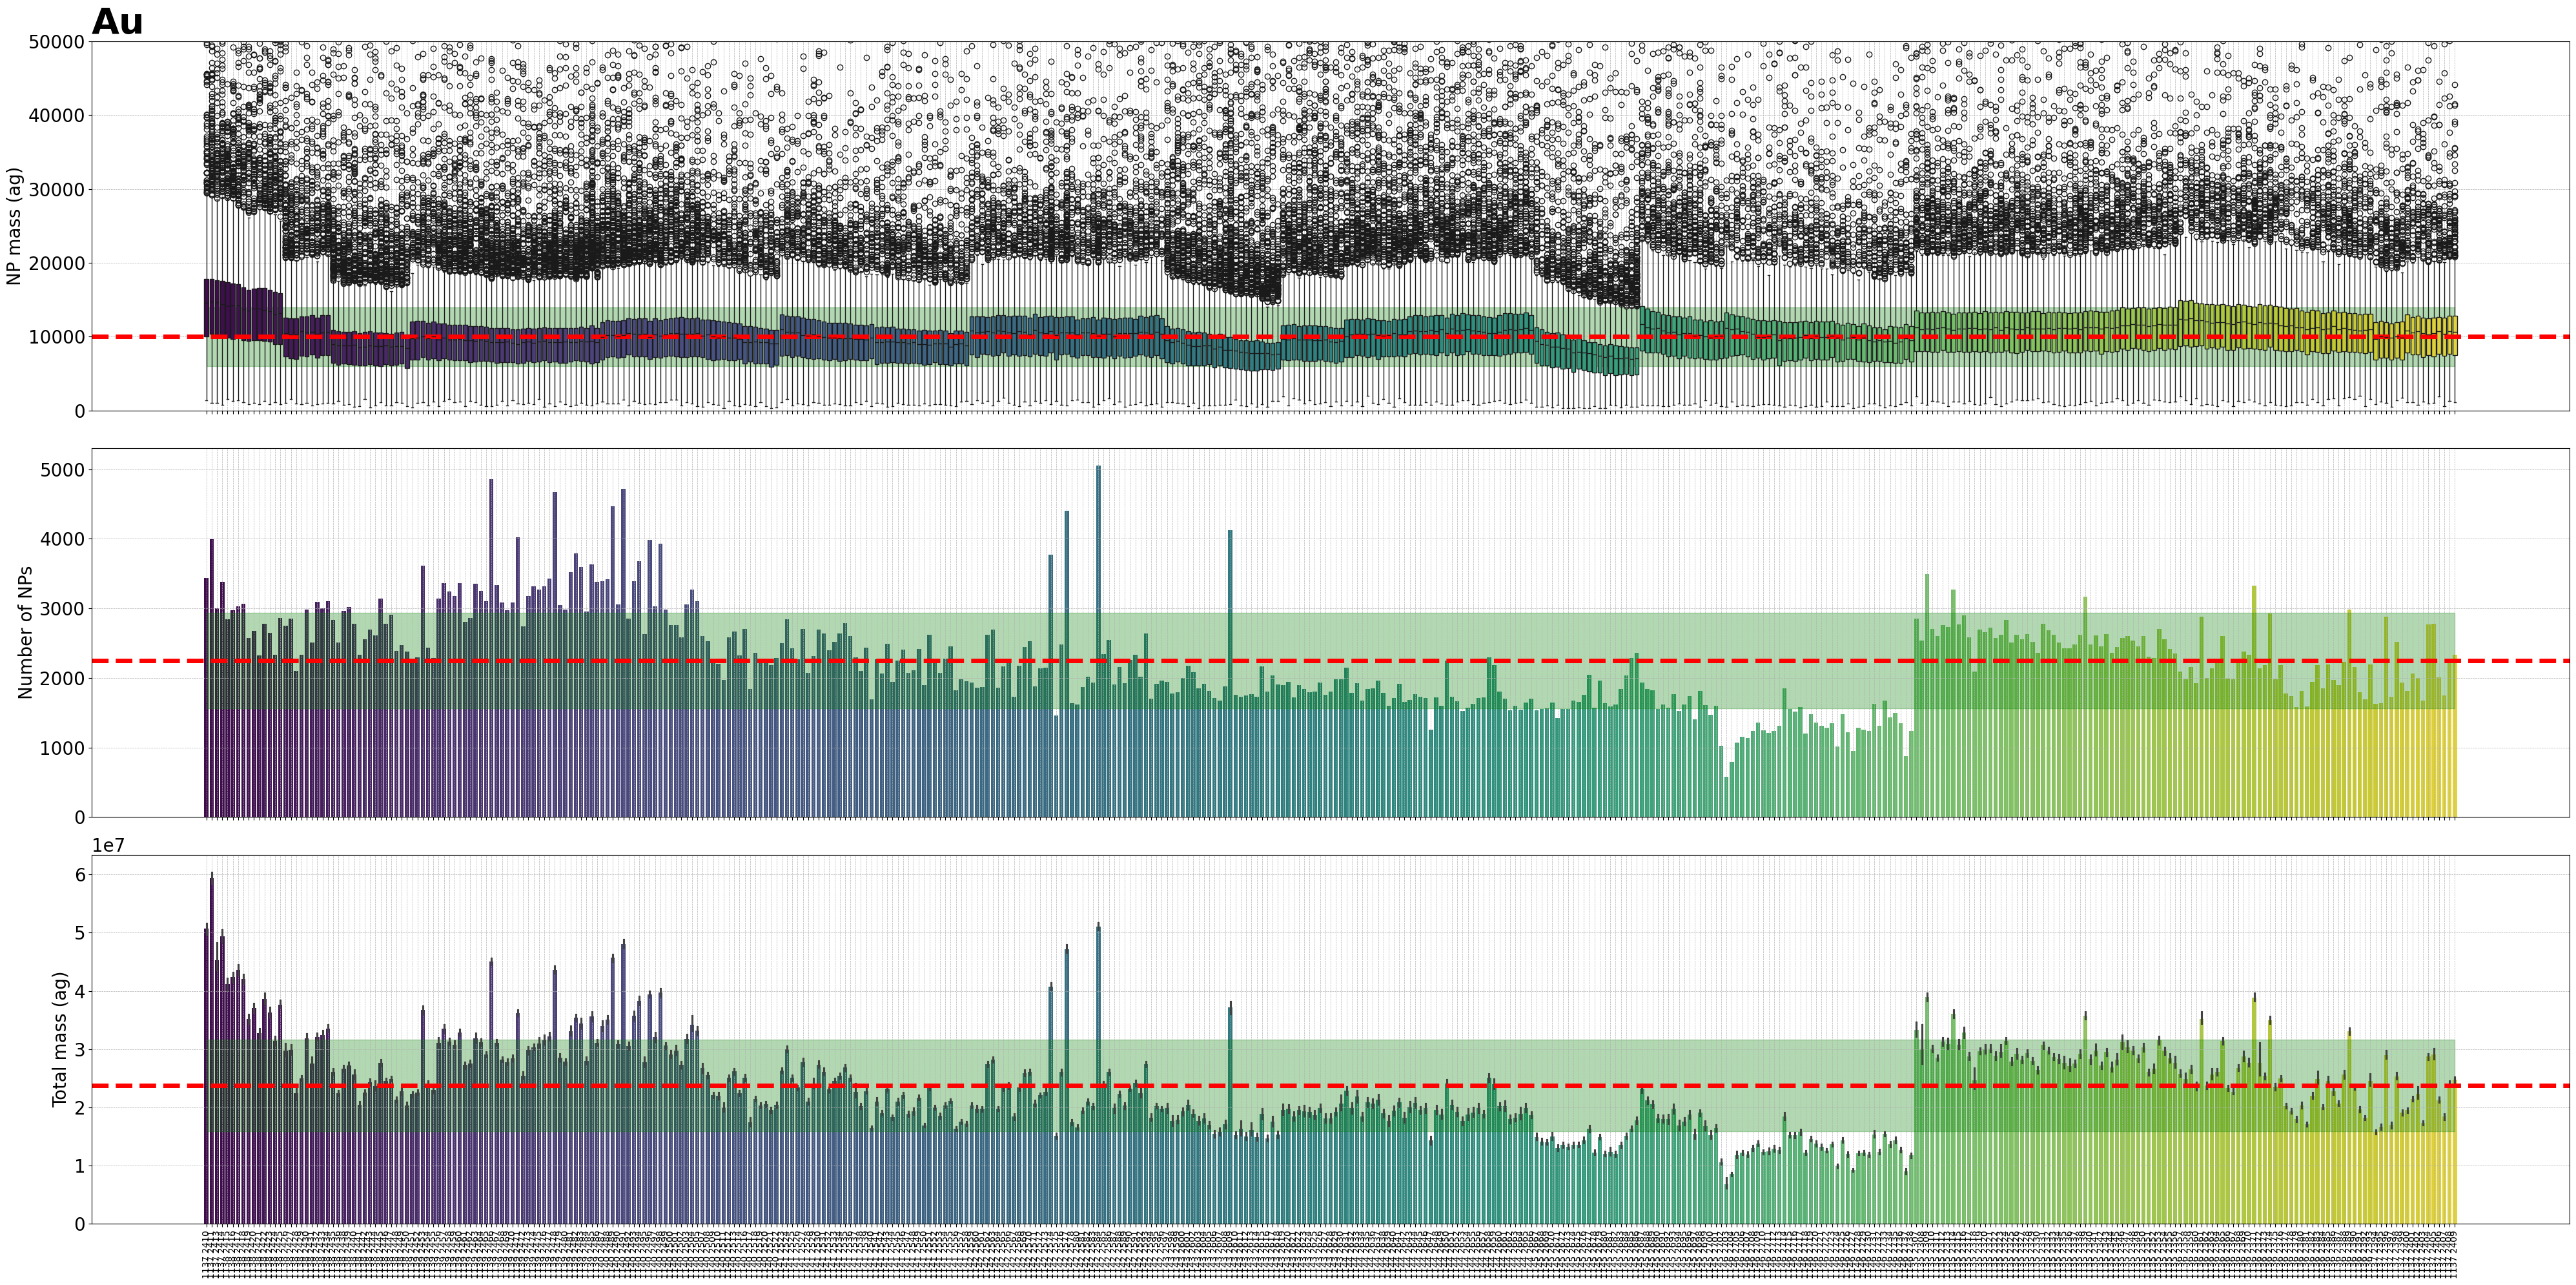

In [7]:
# Plot data for 'Au' with a threshold of 0
plot_Au_data(merged_df_2, 'Au', threshold=0, palette='viridis')